# LO4 Implementation Module Exercise: Build a Dissimilarity Matrix and Run MDS in Python

**Time expectation:** 15–20 minutes

## Goal
You will build a **dissimilarity (distance) matrix** from product/bundle attributes and then use **Multidimensional Scaling (MDS)** to create a 2D perceptual map.

## What you’ll learn
- How to engineer numeric features from bundle attributes  
- Why standardization matters before computing distances  
- How to compute a pairwise Euclidean distance matrix  
- How to run MDS and interpret a perceptual map (closest substitutes + whitespace)

## Data
This exercise uses `candidate_bundles.csv` from the project data pack.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

# Paths (Google Drive project folder preferred)
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
print("Using bundles file:", BUNDLES_PATH.resolve())

Using bundles file: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data/candidate_bundles.csv


In [ ]:
df_bundles = pd.read_csv(BUNDLES_PATH)
df_bundles

,bundle,price_usd,storage_gb,support,ads,family_seats,offline_download
0,Budget,5,50,Standard,Ads,1,No
1,Mid,8,200,Standard,NoAds,4,Yes
2,Premium,15,1000,Priority,NoAds,6,Yes
3,ValuePlus,12,200,Priority,NoAds,4,Yes


## Step 1: Engineer numeric features

We will build a feature matrix using:
- `price_usd`
- `log(storage_gb)`
- `family_seats`
- binary flags: Priority support, No Ads, Offline download

These are simple, interpretable features that let us compute distances between bundles.


In [ ]:
df = df_bundles.copy()

df["log_storage"] = np.log(df["storage_gb"].astype(float))
df["is_priority"] = (df["support"].astype(str) == "Priority").astype(int)
df["is_noads"] = (df["ads"].astype(str) == "NoAds").astype(int)
df["is_offline"] = (df["offline_download"].astype(str) == "Yes").astype(int)

feature_cols = ["price_usd", "log_storage", "family_seats", "is_priority", "is_noads", "is_offline"]
X_raw = df[feature_cols].astype(float).values

df[["bundle"] + feature_cols]

,bundle,price_usd,log_storage,family_seats,is_priority,is_noads,is_offline
0,Budget,5,3.912023,1,0,0,0
1,Mid,8,5.298317,4,0,1,1
2,Premium,15,6.907755,6,1,1,1
3,ValuePlus,12,5.298317,4,1,1,1


## Step 2: Standardize features

Distances are sensitive to scale. For example, `price_usd` and `log_storage` may dominate if we don't standardize.

We standardize to mean 0, std 1 before computing Euclidean distances.


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pd.DataFrame(X, columns=feature_cols, index=df["bundle"])

,price_usd,log_storage,family_seats,is_priority,is_noads,is_offline
bundle,,,,,,
Budget,-1.313064,-1.359659,-1.540308,-1.0,-1.732051,-1.732051
Mid,-0.525226,-0.052597,0.140028,-1.0,0.577350,0.577350
Premium,1.313064,1.464853,1.260252,1.0,0.577350,0.577350
ValuePlus,0.525226,-0.052597,0.140028,1.0,0.577350,0.577350


## Step 3: Compute a Euclidean distance matrix

We'll compute pairwise distances between bundles to form a dissimilarity matrix **D**.


In [ ]:
# Pairwise Euclidean distance matrix
D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))

df_D = pd.DataFrame(D, index=df["bundle"], columns=df["bundle"])
df_D

bundle,Budget,Mid,Premium,ValuePlus
bundle,,,,
Budget,0.000000,3.977348,6.114264,4.751622
Mid,3.977348,0.000000,3.307094,2.259081
Premium,6.114264,3.307094,0.000000,2.044077
ValuePlus,4.751622,2.259081,2.044077,0.000000


## Step 4: Run MDS and plot the perceptual map

We run MDS using the dissimilarity matrix **D** and plot the 2D coordinates.


In [ ]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=7)
coords = mds.fit_transform(D)

df_mds = pd.DataFrame(coords, columns=["x", "y"])
df_mds["bundle"] = df["bundle"].values
df_mds

,x,y,bundle
0,2.860372,-2.224398,Budget
1,0.767744,1.082151,Mid
2,-2.388382,1.339601,Premium
3,-1.239735,-0.197355,ValuePlus


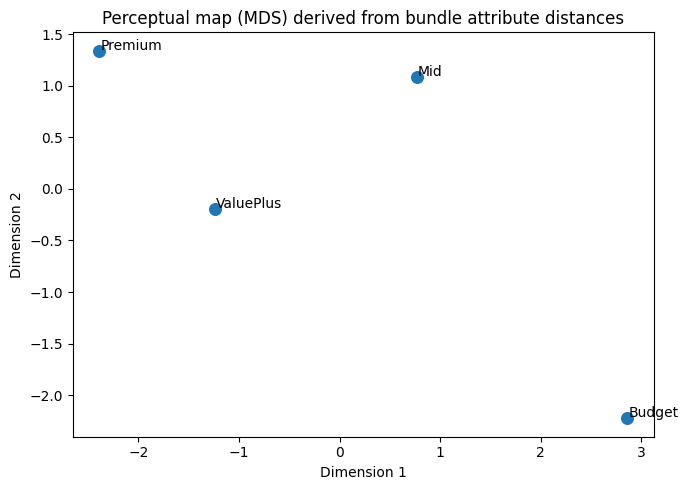

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df_mds["x"], df_mds["y"], s=70)

for _, r in df_mds.iterrows():
    plt.text(r["x"] + 0.01, r["y"] + 0.01, r["bundle"])

plt.title("Perceptual map (MDS) derived from bundle attribute distances")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

## Step 5: Interpret the map (closest substitutes + whitespace)

A practical interpretation:
- **Closest substitutes:** the pair with the smallest distance in **D**
- **Whitespace:** a bundle that sits relatively far from others (potential differentiation)

Below we compute the closest pair and show a simple whitespace heuristic (average distance to others).


In [ ]:
# Closest substitute pair (excluding diagonal)
pairs = []
names = df["bundle"].tolist()
for i in range(len(names)):
    for j in range(i+1, len(names)):
        pairs.append((names[i], names[j], float(D[i, j])))

pairs_sorted = sorted(pairs, key=lambda t: t[2])
closest = pairs_sorted[0]
closest

('Premium', 'ValuePlus', 2.0440765441763373)

In [ ]:
# Whitespace heuristic: average distance to all other bundles
avg_dist = df_D.replace(0.0, np.nan).mean(axis=1).sort_values(ascending=False)
avg_dist

,0
bundle,
Budget,4.947745
Premium,3.821811
Mid,3.181174
ValuePlus,3.018260


### Interpretation (example solution)
Below we convert the computed results into a short, decision-oriented interpretation:
- Closest substitute pair → highest cannibalization risk if positioned similarly  
- Whitespace bundle → strongest differentiation opportunity (positioning angle)

In [16]:
closest_a, closest_b, closest_d = closest
whitespace_bundle = avg_dist.index[0]
whitespace_score = float(avg_dist.iloc[0])

print(f"Closest substitute pair: {closest_a} vs {closest_b} (distance = {closest_d:.3f})")
print(f"Whitespace bundle (most distinct): {whitespace_bundle} (avg distance = {whitespace_score:.3f})")

print("\nInterpretation:")
print(f"- {closest_a} and {closest_b} are the closest substitutes, so positioning them too similarly increases cannibalization risk.")
print(f"- {whitespace_bundle} is the most distinct by average distance, so it has the strongest whitespace/differentiation opportunity.")

Closest substitute pair: Premium vs ValuePlus (distance = 2.044)
Whitespace bundle (most distinct): Budget (avg distance = 4.948)

Interpretation:
- Premium and ValuePlus are the closest substitutes, so positioning them too similarly increases cannibalization risk.
- Budget is the most distinct by average distance, so it has the strongest whitespace/differentiation opportunity.
